In [ ]:
from langgraph_database_backend import chatbot, retrieve_all_threads
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.tools import tool
from langchain_groq import ChatGroq
from langchain_core.messages import BaseMessage , HumanMessage
from langgraph.graph import StateGraph, START, END
from typing import Annotated, TypedDict
from pydantic import BaseModel, Field
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
import os
import requests

# Load environment variables from .env file
load_dotenv(override=True)

# Ensure the Groq API key is set in the environment
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["LANGCHAIN_API_KEY"] = os.getenv("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_ENDPOINT"] = os.getenv("LANGCHAIN_ENDPOINT")
os.environ["LANGCHAIN_PROJECT"] = os.getenv("LANGCHAIN_PROJECT")
os.environ["LANGCHAIN_TRACING_V2"] = os.getenv("LANGCHAIN_TRACING_V2")

# Initialize the Groq Chat LLM with streaming mode enabled
llm_model = ChatGroq(model="llama-3.3-70b-versatile", streaming=True)
print(f"Using model: {llm_model.model_name}")

Using model: llama-3.3-70b-versatile
Using model: llama-3.3-70b-versatile


C:\Users\vvija\AppData\Local\Temp\ipykernel_9160\2397033063.py:3: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import DuckDuckGoSearchRun


In [ ]:
#Tools
# 
search_tool = DuckDuckGoSearchRun(region="us-east-1" ) 


@tool
def calculator(first_num:float,second_num:float,operation:str) -> dict:
    """ 
   perform a basic operation on two numbers. 
   Supported operations are: add, subtract, multiply, divide.
      + means add, - means subtract, * means multiply, / means divide.

    """

    try:
        if operation == "add":
            result = first_num + second_num
        elif operation == "sub":
            result = first_num - second_num
        elif operation == "mul":
            result = first_num * second_num
        elif operation == "div":
            if second_num == 0:
                return {"error": "Division by zero is not allowed."}
            result = first_num / second_num
        else:
            return {"error": "Invalid operation. Please choose from 'add', 'subtract', 'multiply', or 'divide'."}
            
        return {"first_num":first_num, "second_num":second_num, "operation":operation, "result":result}
    except Exception as e:
        return {"error": str(e)}



@tool
def get_stock_price(symbol: str) -> dict:
    """
    Fetch the current stock price for a given stock symbol using a financial API symbol eg ( 'AAPL, 'TSLA')

    """
    url =f"https://www.alphavantage.co/query?function=GLOBAL_QUOTE&symbol={symbol}&apikey=O9VZD9TX8Q6CNXJ5"
    r= requests.get(url)
    return r.json()
   

In [3]:
#make tools list
tools = [search_tool, calculator, get_stock_price]

#make llm aware about the tools
llm_with_tools = llm_model.bind_tools(tools)

In [4]:
#state
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    

In [5]:
#graph nodes:

def chat_node(state:ChatState):
    """ LLM node tthat may answert or request a tool call. """
    messages = state['messages']
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

tool_node = ToolNode(tools)

In [6]:
#Graph structure
graph = StateGraph(ChatState)
graph.add_node("chat_node",chat_node)
graph.add_node("tools",tool_node)

In [7]:
graph.add_edge(START,"chat_node")

#if the LLM asked for a tool . go to theToolNode: else finish
graph.add_conditional_edges("chat_node", tools_condition)

graph.add_edge("tools","chat_node")

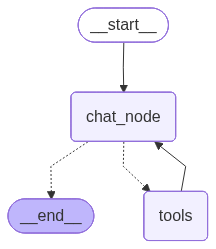

In [8]:
chatbot = graph.compile()
chatbot

In [11]:
#regular chat
out =chatbot.invoke({"messages":[HumanMessage(content="What is the stock price of TSLA")]})
print(out["messages"][-1].content)

The current stock price of TSLA is $393.45.


In [ ]:
# chat requiring  toolcall calcuator

out=chatbot.invoke({"messages":[HumanMessage(content="what is the value of 66 + 77 ? ")]})
print(out["messages"][-1].content)